## Problems with training a neural network

* You can face the _vanishing gradients_ or _exploding gradients_ problem. This is when the gradients become smaller or larger as the gradient calculation goes backward through the DNN, which makes it hard to train the first few layers in the model. 
* The amount of data might not be enough to train such a large model.
* Training may be extremely slow. 
* A model with millions of parameters would severely risk overfitting the training set, especially if there are not enough training instances or if they are too noisy.

## The Vanishing/Exploding Gradients Problems

The problem is that with vanishing gradients, the gradients get smaller and smaller as backpropagation progresses backwards towards the first few layers in the model, which makes the weight update for these layers insignificant, leaving them virtually unchanged. On the other hand, with exploding gradients, the first few layers get updates with very large values, making the weights diverge and net reach a good solution. This is most commonly the situation in recurrent neural networks. 

The old initialization scheme used to be choosing random values from the normal distribution with a mean of 0 and a standard deviation of 1. Additionally, the sigmoid activation function was commonly used in the early days of DNN. The problem with this configuration is that the outputs of each layer have more variance than the inputs, meaning that the variance keeps increasing as the information propagates forward in the model. 

This variance continues to increase until the activation function saturates at the top layers. When the activation function saturates, the backpropagation calculates a derivative that is extremely close to 0, which means that virtually no gradient propagates back through the network. 

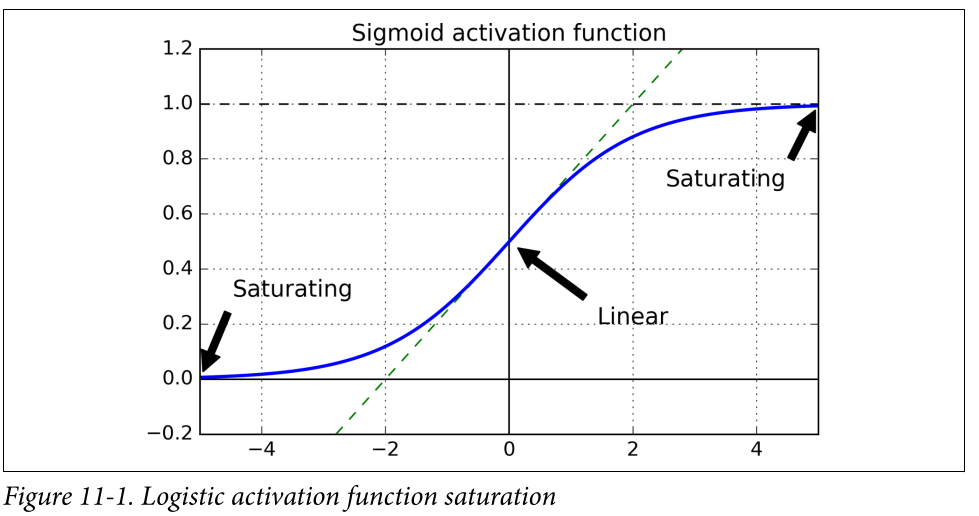

## Glorot and He Initialization

The general idea to combat the exploding/vanishing gradients problem is to make sure that the variance of the input is the same as the variance of the output for layer in both directions (forward and backward). However, this is not possible to achieve unless the number of inputs is equal to the number of outputs in each layer. Fortunately, Glorot and Bengio proposed a good compromise that has proven to work well in practice. The solution is the following:
initialize the layers weights using the following random distributions: 

$fan_{avg} = \frac{(fan_{in} + fan_{out})}{2}$

For the normal distribution initialization, the mean must be 0, and the variance must be:

$\sigma^2 = \frac{1}{fan_{avg}}$

for the uniform distribution between -r and +r, with r:

$r = \sqrt{\frac{3}{fan_{avg}}}$


LeCun initialization is equivalent to Glorot initialization when $fan_{in} = fan_{out}$, it used to substitute $fan_{in}$ in the equation described above, but Glorot proposed using $fan_{avg}$ instead, which lead to much better results. 

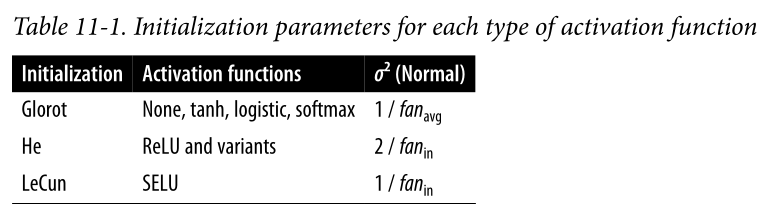

By default, Keras uses the Glorot initialization with a uniform distribution. You can chang this by setting the kernel_initializer parameter as follows:

In [1]:
import tensorflow as tf, keras
keras.layers.Dense(10, activation = 'relu', kernel_initializer='he_normal')

2024-08-31 17:44:37.259908: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-31 17:44:37.276358: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-31 17:44:37.281624: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-31 17:44:37.294828: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-31 17:44:38.040294: W tensorflow/compiler/tf2

<Dense name=dense, built=False>

If you want to use He initialization but use $fan_{avg}$ instead of $fan_{in}$, you can do it as follows:

In [3]:
he_avg_init = keras.initializers.VarianceScaling(scale = 2.0, mode = 'fan_avg', distribution='uniform')
keras.layers.Dense(10, activation = 'sigmoid', kernel_initializer=he_avg_init)

<Dense name=dense_1, built=False>